# Foot Trajectory Analysis by Dance Mode

This notebook provides trajectory visualization tools organized by dance performance modes (group, individual, audience), with multiple alignment strategies for analyzing foot movement patterns across different performance contexts.

## Overview

The notebook creates trajectory visualizations organized by dance mode, including:
- **Subdivision-aligned trajectories** in multi-panel layouts (2x2 subplots)
- **Beat-aligned trajectories** organized by beat position (1, 2, 3, 4)
- **Cycle-aligned trajectories** showing all cycles with grand averages
- **Mode-based segmentation** automatically extracting time segments for each performance mode

## Features

- **Dance mode organization**: Automatically extracts and processes time segments for group, individual, and audience modes
- **Multiple alignment strategies**: Visualize trajectories aligned to subdivisions, beats, or full cycles
- **Batch processing**: Process all recordings and modes automatically
- **Flexible visualization controls**: Toggle trajectory lines, vertical markers, and gray background plots
- **Grand average calculation**: Compute and display average trajectories across all cycles
- **Mode-specific output**: Organize outputs by performance mode for comparative analysis

## Workflow

1. **Mode Segmentation**: Extract time segments for each dance mode from annotation files
2. **Subdivision Analysis**: Generate 2x2 subplot layouts aligned to specific subdivisions
3. **Beat Analysis**: Create multi-panel plots organized by beat positions
4. **Cycle Analysis**: Visualize all cycles with grand averages
5. **Batch Processing**: Automatically process all recordings and modes
6. **Output Organization**: Organize plots by mode for easy comparison

## Prerequisites

- Foot position CSV files (`data/logs_v1_may/`, `data/logs_v2_may/`, or other log versions)
- Virtual cycle CSV files (`data/virtual_cycles/`)
- Foot onset CSV files (`data/logs_*/.../onset_info/`)
- Dance mode annotation CSV files (`data/subset_dance_annotation/`)

## Output

- **Subdivision plots**: PNG files with 2x2 subplots showing trajectories aligned to specific subdivisions
- **Beat plots**: Multi-panel layouts organized by beat positions
- **Cycle plots**: Single plots showing all cycles with grand averages
- **Organized by mode**: Outputs saved in mode-specific directories for easy comparison

All outputs are saved to `output_static_plot/` with subdirectories for each plot type and mode.

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bvh_converter import bvh_mod
from scipy.signal import savgol_filter

from matplotlib.lines import Line2D
from scipy.interpolate import interp1d

from utils_trajectory.trajectory_by_subdiv import plot_foot_trajectories_by_subdiv
from utils_trajectory.trajectory_by_beat import plot_foot_trajectories_by_beat
from utils_trajectory.trajectory_cycle import plot_cycles_trajectories_by_threshold
from utils_pipeline.pipeline_A import *

### For pptx: big font, remove title etc

In [ ]:
def plot_cycles_trajectories_by_threshold(
    file_name: str,
    mode: str,
    pelvis_zpos: np.ndarray,  # New parameter
    base_path_cycles: str = "data/virtual_cycles",
    base_path_logs: str = "data/dance_onsets_v4_0.007_foot_jun3",
    frame_rate: float = 240,
    time_segments: list = None,  # List of (start, end) tuples
    n_beats_per_cycle: int = 4,
    n_subdiv_per_beat: int = 3,
    traj_threshold=0.15,
    figsize: tuple = (12, 12),  # Increased height for two plots
    dpi: int = 200,
    show_trajectories: bool = True,  # Control trajectory lines
    show_vlines: bool = True,        # Control vertical lines
    show_gray_plots: bool = True     # Control gray trajectory plots
):
    """
    Plot all foot trajectories in a single plot with grand average.
    Shows beat and subdivision lines with colors.
    X-axis shows 1.5 cycles (e.g., 0-6 for 4-beat cycles).
    Top subplot shows pelvis trajectories for included cycles.
    """
    print(time_segments)
    # Use default window if no segments provided
    if time_segments is None:
        time_segments = [(0, 10)]

    # build file paths
    cycles_csv = os.path.join(base_path_cycles, f"{file_name}_C.csv")
    logs_onset_dir = os.path.join(base_path_logs, f"{file_name}_T", "onset_info")
    left_onsets_csv  = os.path.join(logs_onset_dir, f"{file_name}_T_left_foot_onsets.csv")
    right_onsets_csv = os.path.join(logs_onset_dir, f"{file_name}_T_right_foot_onsets.csv")
    left_zpos_csv    = os.path.join(logs_onset_dir, f"{file_name}_T_left_foot_zpos.csv")
    right_zpos_csv   = os.path.join(logs_onset_dir, f"{file_name}_T_right_foot_zpos.csv")

    # load data
    Lz = pd.read_csv(left_zpos_csv)["zpos"].values
    Rz = pd.read_csv(right_zpos_csv)["zpos"].values
    n_frames = len(Lz)
    times = np.arange(n_frames) / frame_rate

    # interpolation functions
    L_interp = interp1d(times, Lz, bounds_error=False, fill_value="extrapolate")
    R_interp = interp1d(times, Rz, bounds_error=False, fill_value="extrapolate")

    # Get overall time range for color mapping
    total_start = min(seg[0] for seg in time_segments)
    total_end = max(seg[1] for seg in time_segments)
    t_range = total_end - total_start

    # Get all onsets
    all_onsets = []
    for seg_start, seg_end in time_segments:
        cyc_df = pd.read_csv(cycles_csv)
        cyc_df = cyc_df[(cyc_df["Virtual Onset"] >= seg_start) & (cyc_df["Virtual Onset"] <= seg_end)]
        if not cyc_df.empty:
            all_onsets.extend(cyc_df["Virtual Onset"].values[:-1])
    
    if not all_onsets:
        raise ValueError("No cycles found in any of the time segments")
    
    # Sort onsets
    all_onsets = np.sort(all_onsets)

    # Create figure with two subplots
    fig, (ax_pelvis, ax_feet) = plt.subplots(2, 1, figsize=figsize, dpi=dpi, sharex=True)
    cmap = plt.get_cmap('cool')

    # Define subdivision color mapping
    def get_subdiv_color(subdiv):
        total_subdiv = n_beats_per_cycle * n_subdiv_per_beat
        subdiv = ((subdiv - 1) % total_subdiv) + 1
        group = ((subdiv - 1) % 3) + 1
        if group == 1:
            return 'black'
        elif group == 2:
            return 'green'
        elif group == 3:
            return 'red'
        return 'gray'

    # Process each time segment
    all_L_trajectories = []
    all_R_trajectories = []
    all_times = []
    included_cycles = []  # New list to store cycle start times
    excluded_cycles = []    # New list to store cycle end times
    all_pelvis_trajectories = [] 
    
    for seg_start, seg_end in time_segments:
        # trim to window
        win_mask = (times >= seg_start) & (times <= seg_end)
        t_win = times[win_mask]
        L_win = Lz[win_mask]*100    # convert to cm
        R_win = Rz[win_mask]*100    # convert to cm
        pelvis_win = pelvis_zpos[win_mask]*100   # Get pelvis data for this window

        # cycles (downbeats)
        cyc_df = pd.read_csv(cycles_csv)
        cyc_df = cyc_df[(cyc_df["Virtual Onset"] >= seg_start) & (cyc_df["Virtual Onset"] <= seg_end)]
        onsets = cyc_df["Virtual Onset"].values[:-1]

        # foot onsets
        left_df  = pd.read_csv(left_onsets_csv)
        right_df = pd.read_csv(right_onsets_csv)
        left_times  = left_df[(left_df["time_sec"]>=seg_start)&(left_df["time_sec"]<=seg_end)]["time_sec"].values
        right_times = right_df[(right_df["time_sec"]>=seg_start)&(right_df["time_sec"]<=seg_end)]["time_sec"].values

        # Plot trajectories for each cycle
        for i, c in enumerate(onsets):
            # Get cycle start and end from actual onsets
            cycle_start = c
            cycle_end = onsets[i + 1] if i < len(onsets) - 1 else c + (onsets[1] - onsets[0])  # fallback to first cycle duration
            cycle_duration = cycle_end - cycle_start
            beat_len = cycle_duration / n_beats_per_cycle
            
            m = (t_win >= cycle_start) & (t_win <= cycle_end)
            tr = (t_win[m] - cycle_start) / beat_len  # normalize to 0-4 beats

            if show_trajectories:
                col = cmap((c-total_start)/t_range) # ------------------------
                has_any_onsets = any(cycle_start <= t <= cycle_end for t in left_times) or any(cycle_start <= t <= cycle_end for t in right_times)
                
                # Plot gray trajectories only for cycles without any onsets
                if show_gray_plots and not has_any_onsets:
                    ax_feet.plot(tr, L_win[m], '-', color='gray', alpha=0.2)
                    ax_feet.plot(tr, R_win[m], '--', color='gray', alpha=0.2)
                    # Also plot shifted for 1.5 cycles
                    # ax_feet.plot(tr, L_win[m], '-', color='gray', alpha=0.9)
                    # ax_feet.plot(tr, R_win[m], '--', color='gray', alpha=0.9)
                
                # Plot colored trajectories for cycles with any onsets
                if has_any_onsets:
                    ax_feet.plot(tr, L_win[m], '-', color= "blue", alpha=0.2, label="Left Foot" if c==onsets[0] else "")
                    ax_feet.plot(tr, R_win[m], '-', color= "red", alpha=0.2, label="Right Foot" if c==onsets[0] else "")
                
                # Apply thresholding when storing trajectories for averaging
                traj_max = max(np.nanmax(L_win[m]), np.nanmax(R_win[m]))
                if traj_max >= traj_threshold:
                    all_L_trajectories.append(L_win[m])
                    all_R_trajectories.append(R_win[m])
                    all_pelvis_trajectories.append(pelvis_win[m])  # Add pelvis trajectory
                    all_times.append(tr)
                    # Store the cycle timing information for included trajectories
                    included_cycles.append((cycle_start, cycle_end))
                    # Plot pelvis trajectory for included cycles
                    ax_pelvis.plot(tr, pelvis_win[m], '-', color= "green", alpha=0.2)

                else:
                    excluded_cycles.append((cycle_start, cycle_end))

                # Plot markers for foot onsets
                for lt in left_times:
                    if cycle_start <= lt <= cycle_end:
                        rel = (lt - cycle_start) / beat_len
                        if show_vlines:
                            ax_feet.axvline(rel, color=col, linestyle='-', alpha=0.5)
                        ax_feet.plot(rel, L_interp(lt), 'o', ms=10, markeredgecolor='k', 
                                markerfacecolor='blue', alpha=0.8, zorder=3)


                for rt in right_times:
                    if cycle_start <= rt <= cycle_end:
                        rel = (rt - cycle_start) / beat_len
                        if show_vlines:
                            ax_feet.axvline(rel, color=col, linestyle='--', alpha=0.5)
                        ax_feet.plot(rel, R_interp(rt), 'o', ms=10, markeredgecolor='k', 
                                color='red', alpha=0.8, zorder=3)

    
    print("count of included trajectories: ", len(included_cycles))
    print("count of excluded trajectories: ", len(excluded_cycles))
    # print(included_cycles)
    
    # Save the dictionaries --------------------------------------------------------------
    pickle_dir = "traj_files_presentation"
    os.makedirs(pickle_dir, exist_ok=True)
    
    with open(os.path.join(pickle_dir, f'{file_name}_included_{traj_threshold}.pkl'), 'wb') as f:
        pickle.dump(included_cycles, f)
    
    with open(os.path.join(pickle_dir, f'{file_name}_excluded_{traj_threshold}.pkl'), 'wb') as f:
        pickle.dump(excluded_cycles, f)
    
    # -------------------------------------------------------------------------------------
    
    # Calculate and plot grand average for feet
    if all_L_trajectories and all_R_trajectories and all_pelvis_trajectories:
        # Interpolate all trajectories to the same time points
        common_times = np.linspace(0, n_beats_per_cycle, 100)
        L_avg = np.zeros(len(common_times))
        R_avg = np.zeros(len(common_times))
        pelvis_avg = np.zeros(len(common_times))  # New array for pelvis average
        count = 0
        
        for L_traj, R_traj, P_traj, t_traj in zip(all_L_trajectories, all_R_trajectories, all_pelvis_trajectories, all_times):
            L_interp = interp1d(t_traj, L_traj, bounds_error=False, fill_value="extrapolate")
            R_interp = interp1d(t_traj, R_traj, bounds_error=False, fill_value="extrapolate")
            P_interp = interp1d(t_traj, P_traj, bounds_error=False, fill_value="extrapolate")  # New interpolation
            L_avg += L_interp(common_times)
            R_avg += R_interp(common_times)
            pelvis_avg += P_interp(common_times)  # Add to pelvis average
            count += 1
        
        if count > 0:
            L_avg /= count
            R_avg /= count
            pelvis_avg /= count  # Normalize pelvis average
            
            # Plot foot averages
            ax_feet.plot(common_times, L_avg, '-', color='blue', linewidth=4, label='Left Foot Average', alpha=0.9)
            ax_feet.plot(common_times, R_avg, '-', color='red', linewidth=4, label='Right Foot Average', alpha=0.9)
            # ax_feet.plot(common_times, L_avg, '-', color='blue', linewidth=3)
            # ax_feet.plot(common_times, R_avg, '--', color='red', linewidth=3)
            
            # Plot pelvis average
            ax_pelvis.plot(common_times, pelvis_avg, '-', color='green', linewidth=4, label='Pelvis Average')
            # ax_pelvis.plot(common_times, pelvis_avg, '-', color='purple', linewidth=3)

    # Add vertical lines and grid for both subplots
    for ax in [ax_pelvis, ax_feet]:
        # Add vertical line at position 0 (will display as 1)
        ax.axvline(0, color='black', linewidth=2, alpha=0.8)
        ax.axvline(4, color='black', linewidth=2, alpha=0.8)  # Start of second cycle

        # Add beat and subdivision lines for 1.5 cycles
        for cycle in range(1):  # 0 and 1
            for beat in range(1, n_beats_per_cycle + 1):
                pos = cycle * n_beats_per_cycle + beat
                ax.axvline(pos, color='black', linewidth=2, alpha=1)
                # Add subdivision lines
                for subdiv in range(1, n_subdiv_per_beat):
                    subdiv_pos = cycle * n_beats_per_cycle + (beat - 1) + subdiv / n_subdiv_per_beat
                    subdiv_num = (beat - 1) * n_subdiv_per_beat + subdiv + 1
                    grid_color = get_subdiv_color(subdiv_num)
                    ax.axvline(subdiv_pos, color=grid_color, alpha=0.4, linewidth=1.0, linestyle='--')

        # Set x-axis for 1.5 cycles
        # xticks = [0.0, 0.33, 0.67, 1.0, 1.33, 1.67, 2.0, 2.33, 2.67, 3.0, 3.33, 3.67, 4.0]
        xticks = [0, 1, 2, 3, 4]
        xticklabels = [1, 2, 3, 4, 5]
        # xticklabels = ['1.00', '1.33', '1.67', '2.00', '2.33', '2.67', '3.00', '3.33', '3.67', '4.00', '4.33', '4.67', '5.00']
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)  # Label as 1-based
        ax.set_xlim(0.0, 4)
        ax.grid(True, alpha=0.3)

    # Set labels and titles
    ax_pelvis.set_ylabel("Pelvis", fontsize=12)
    ax_feet.set_ylabel("Feet", fontsize=12)
    ax_feet.set_xlabel("4-beat cycle span", fontsize=12)
    
    # Set titles
    ax_pelvis.set_title(f"{file_name} | {mode}")
    # ax_pelvis.set_title(f"{file_name} | Pelvis Trajectories | {mode}")
    # ax_feet.set_title(f"{file_name} | Foot Trajectories | {mode} | Threshold: {traj_threshold}")
    
    # Add all legends together outside the plot
    custom = [
        # Line2D([0],[0],marker='o', color='w', markerfacecolor='blue', ms=8, markeredgecolor='k'),
        # Line2D([0],[0],marker='x', color='red', ms=8),
        Line2D([0],[0],color='blue', lw=1.5),
        Line2D([0],[0],color='red', lw=1.5, linestyle='-'),
        # Line2D([0],[0],color='green', lw=3),  # Add pelvis average to legend
        # Line2D([0],[0],color='gray', lw=1.5),
        # Line2D([0],[0],color='black', lw=1.5),
        # Line2D([0],[0],color='green', lw=1.5),
        # Line2D([0],[0],color='red', lw=1.5)
    ]
    labels = [
        # "Left Onset", 
        # "Right Onset", 
        "Left Foot", 
        "Right Foot", 
        # "Pelvis Average",  # Add pelvis average label
        # "Undetected trajectory",
        # "Subdivision 1 (1,4,7,10)", 
        # "Subdivision 2 (2,5,8,11)", 
        # "Subdivision 3 (3,6,9,12)"
    ]

    ax_feet.legend(custom, labels, loc='upper left', framealpha=0.3)
    # Create a new axes for the legend
    # legend_ax = fig.add_axes([0.9, 0.1, 0.1, 0.8])
    # legend_ax.axis('off')
    # legend_ax.legend(custom, labels, loc='center left', framealpha=0.3)

    # Add colorbar
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(total_start, total_end))
    # sm.set_array([])
    # cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.8])
    # plt.colorbar(sm, cax=cbar_ax, label='Time in recording (s)')

    # Adjust layout to make room for legend and colorbar
    fig.subplots_adjust(right=0.85)
    
    return fig, (ax_pelvis, ax_feet)

### Visualize trajectories with thresholding and average

[(141.52, 161.38), (164.455, 176.944), (227.2, 250.829), (286.7, 313.739)]
count of included trajectories:  69
count of excluded trajectories:  0


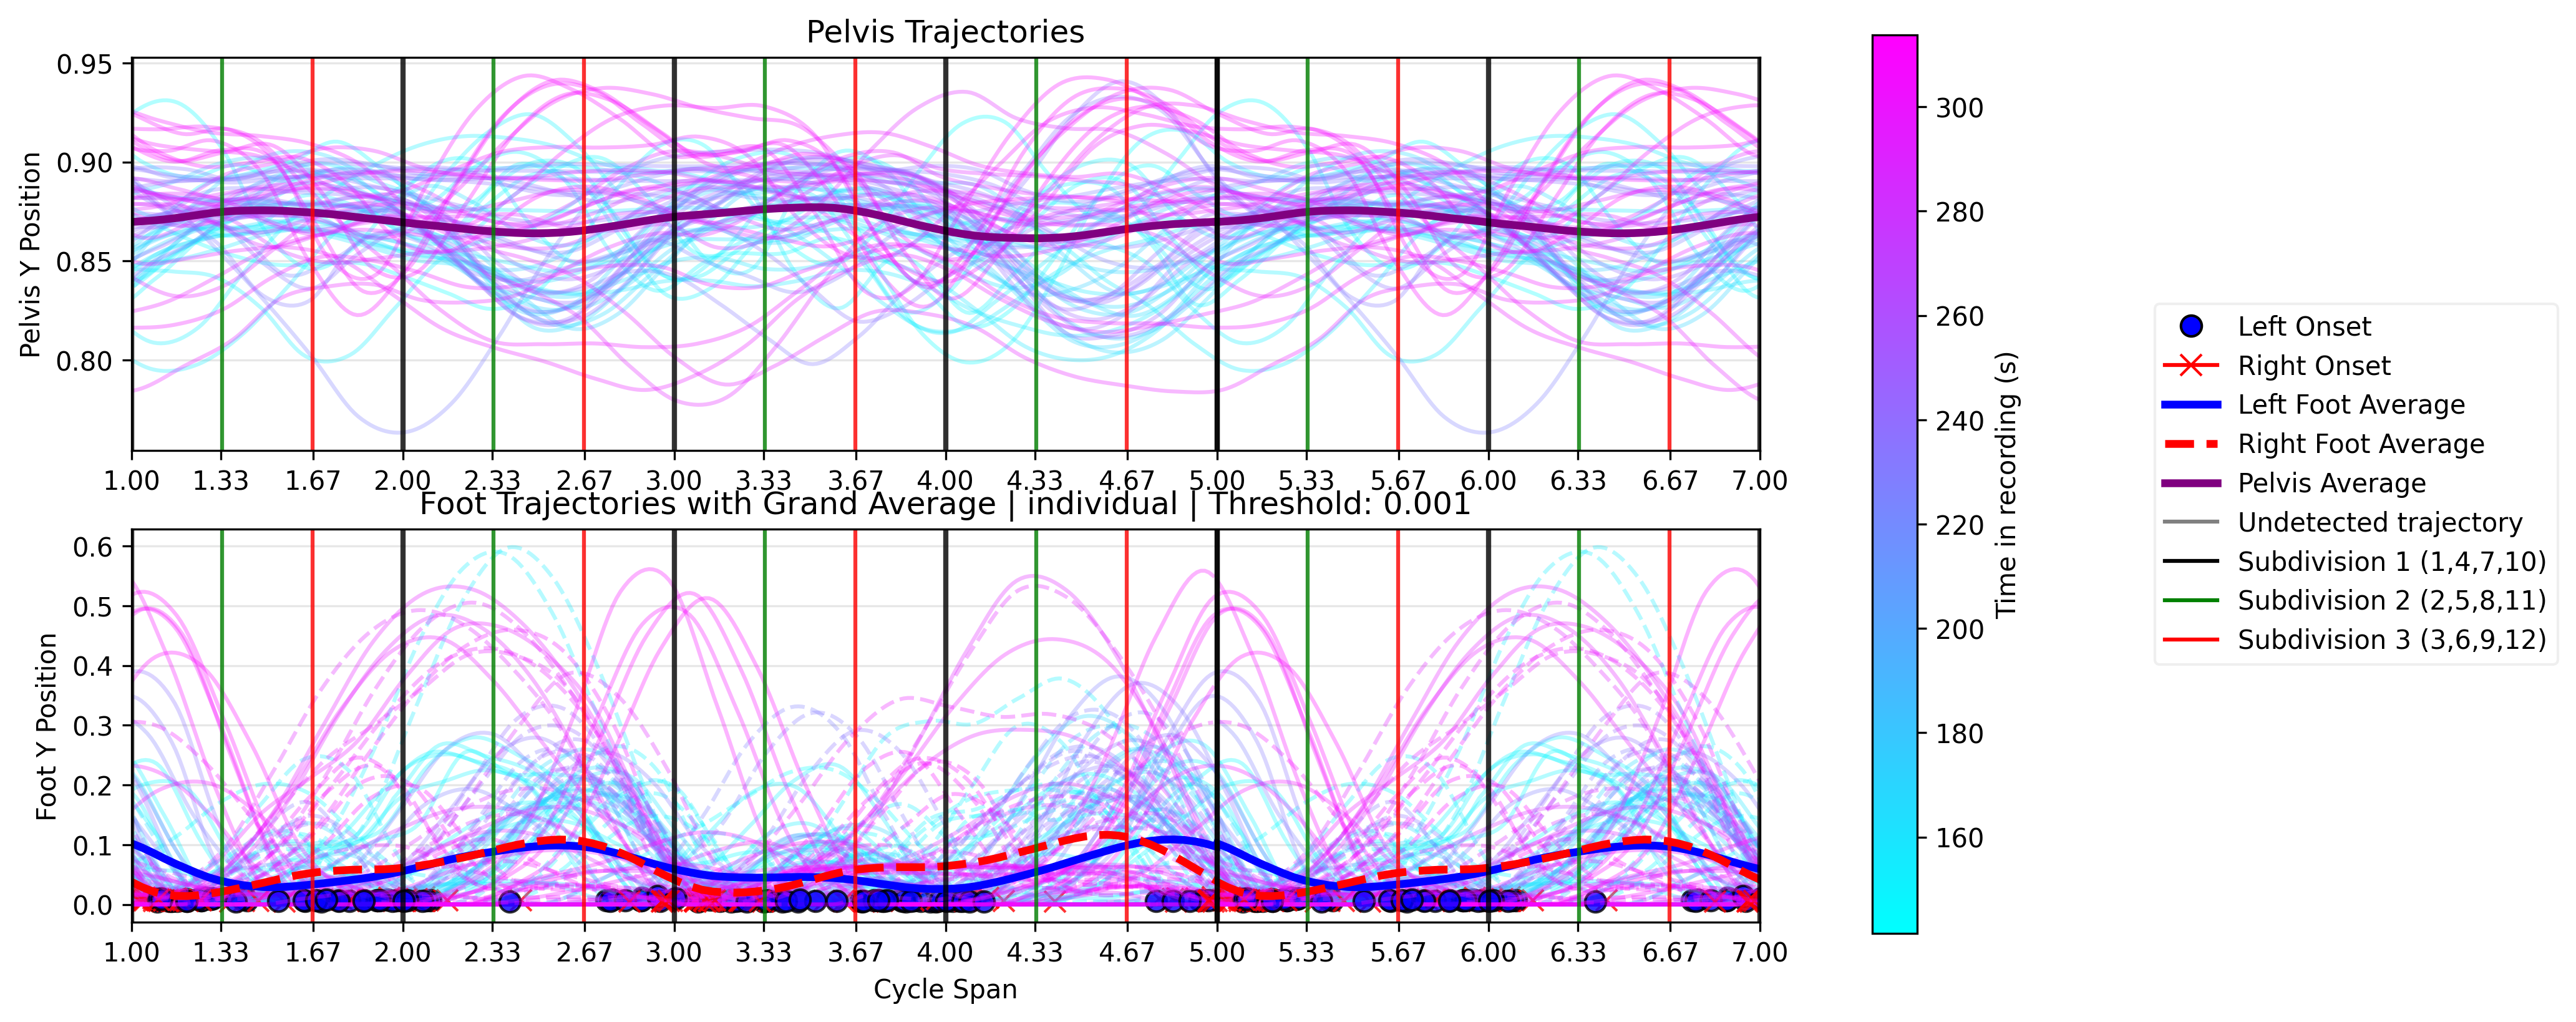

In [6]:
with open('data/selected_piece_list.pkl', 'rb') as f:
    piece_list = pickle.load(f)

motion_data_dir = "data/motion_data_pkl"

for file_name in piece_list:

    mode_df = pd.read_csv("data/subset_dance_annotation/" + file_name + "_Dancers.csv")

    # Load the pickle file
    mpkl_path = f"{motion_data_dir}/{file_name}_T.pkl"

    with open(mpkl_path, 'rb') as f:
        motion_data = pickle.load(f)

    # pelvis_zpos = motion_data["position"]['SEGMENT_PELVIS'][:,2]
    pelvis_zpos = motion_data['segments']['Pelvis']["position"][:,2]

    mode_group = mode_df[mode_df["mocap"] == "gr"].reset_index(drop=True)
    mode_individual = mode_df[mode_df["mocap"] == "in"].reset_index(drop=True)
    mode_audience = mode_df[mode_df["mocap"] == "au"].reset_index(drop=True)

    # dict of segments
    segments = {
        "group":      get_segments(mode_group,      "gr"),
        "individual": get_segments(mode_individual, "in"),
        "audience":   get_segments(mode_audience,   "au")
    }


    # mode_name, segmnt = get_tsegment_for("group", mode_group,      "gr")
    mode_name, segmnt = get_tsegment_for("individual", mode_individual, "in")
    # mode_name, segmnt   = get_tsegment_for("audience",   mode_audience,   "au")

    if segmnt is None:
        continue
    
    save_dir = f"output_static_plot/trajectory_pelvis_feet/{mode_name}"
    os.makedirs(save_dir, exist_ok=True)

    fig, ax = plot_cycles_trajectories_by_threshold(
                file_name=file_name,
                mode=mode_name,
                pelvis_zpos = pelvis_zpos,
                base_path_cycles="data/virtual_cycles", 
                base_path_logs="data/logs_v4_0.007_foot_jun3",          # "data/logs_v2_may",
                time_segments= segmnt,  # Pass all time segments for this mode
                n_beats_per_cycle=4, 
                n_subdiv_per_beat=3, 
                traj_threshold=0.001,     # exclude trajectories below this threshold
                show_gray_plots= True,
                show_trajectories= True,  # New parameter to control trajectory lines
                show_vlines= False,        # New parameter to control vertical lines,
                figsize=(12, 6),
                dpi=300,
            )

    plt.show(fig)
    break
    # save_dir = f"output_static_plot/new/"
    # os.makedirs(save_dir, exist_ok=True)
    # fig.savefig(os.path.join(save_dir, f"{file_name}_{mode_name}.png"), dpi=300)
    # plt.close(fig)